# Lab Assignment: Exploratory Data Analysis with Pandas

**Goal**: Implement data manipulation and visualization using only Pandas-native functions.

**Note**: Use the provided synthetic data to complete the questions. Focus on using `df.plot()` and other Pandas-specific methods.

In [1]:
import pandas as pd
import numpy as np

# Setup for the lab
np.random.seed(42)
n = 200
data = {
    'product_id': range(1, n + 1),
    'category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Groceries'], n),
    'price': np.random.uniform(10, 500, n).round(2),
    'units_sold': np.random.randint(1, 100, n),
    'rating': np.random.uniform(1, 5, n).round(1),
    'in_stock': np.random.choice([True, False], n)
}
df = pd.DataFrame(data)
print('Dataset prepared for assignment.')

Dataset prepared for assignment.


### Question 1: Initial Exploration

**Task**: Use Pandas functions to identify the total number of rows/columns, the data types of each column, and the count of missing values.

**Hints**:
- Check `.shape` for dimensions.
- Use `.info()` for types and null counts.
- Use `.describe()` for a statistical overview.

In [2]:
# Write your code for Question 1 here
print("Shape : ", df.shape)

df.info()


df.describe()

Shape :  (200, 6)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   product_id  200 non-null    int64  
 1   category    200 non-null    str    
 2   price       200 non-null    float64
 3   units_sold  200 non-null    int32  
 4   rating      200 non-null    float64
 5   in_stock    200 non-null    bool   
dtypes: bool(1), float64(2), int32(1), int64(1), str(1)
memory usage: 7.4 KB


,product_id,price,units_sold,rating
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,258.781200,50.145000,3.030500
std,57.879185,143.422716,29.963864,1.220396
min,1.000000,12.480000,1.000000,1.000000
25%,50.750000,131.500000,23.000000,1.900000
50%,100.500000,265.055000,50.500000,3.000000
75%,150.250000,384.217500,76.000000,4.100000
max,200.000000,495.130000,99.000000,5.000000


### Question 2: Advanced Filtering

**Task**: Create a new DataFrame containing only the 'Electronics' and 'Clothing' categories where the `price` is above the average price of the entire dataset.

**Hints**:
- Use `.mean()` to calculate the threshold.
- Use boolean indexing or `.query()` for filtering.

In [3]:
# Write your code for Question 2 here
# Calculate average price
avg_price = df['price'].mean()

# Filter data
filtered_df = df[
    (df['category'].isin(['Electronics', 'Clothing'])) &
    (df['price'] > avg_price)
]

print(filtered_df.head())


    product_id     category   price  units_sold  rating  in_stock
7            8  Electronics  380.22          16     2.5     False
15          16  Electronics  437.02          58     3.2     False
20          21     Clothing  405.65          23     1.0     False
21          22  Electronics  449.08           9     2.9      True
26          27     Clothing  410.83          34     4.0      True


### Question 3: Grouping and Aggregation

**Task**: Find the total revenue (Price * Units Sold) per category. Sort the result from highest to lowest revenue.

**Hints**:
- Create a new column first.
- Use `.groupby()` and `.sum()`.
- Use `.sort_values()`.

In [4]:
# Write your code for Question 3 here
# Create revenue column
df['revenue'] = df['price'] * df['units_sold']

# Group by category and sum revenue
revenue_by_category = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

print(revenue_by_category)


category
Groceries      776467.68
Home           716885.15
Electronics    561996.70
Clothing       528857.79
Name: revenue, dtype: float64


### Question 4: Data Visualization (Pandas Only)

**Task**: Generate the following plots using the `df.plot()` method:
1. A **bar chart** showing the average rating per category.
2. A **scatter plot** relating 'price' to 'units_sold'.
3. A **histogram** of the 'price' distribution.

**Hints**:
- For the bar chart, you must aggregate the data first.
- Use the `kind` parameter (e.g., `kind='bar'`, `kind='scatter'`, `kind='hist'`).

<Axes: title={'center': 'Price vs Units Sold'}, xlabel='price', ylabel='units_sold'>

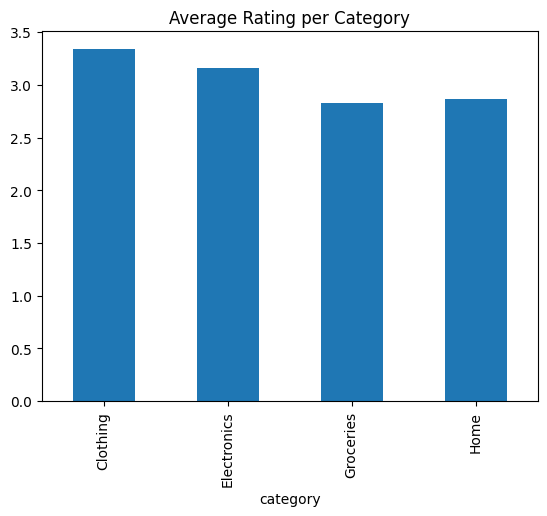

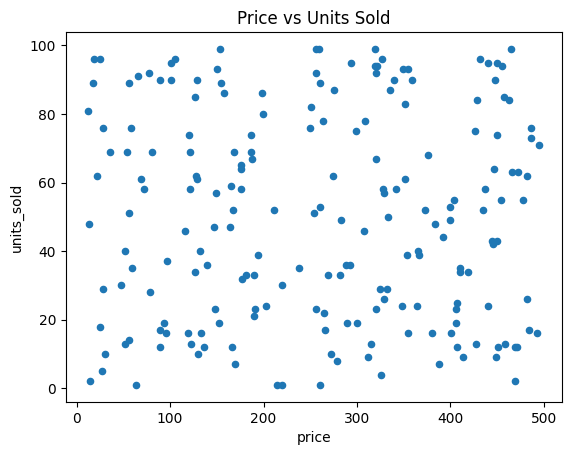

In [5]:
# Write your code for Question 4 here
# 1. Bar chart - average rating per category
avg_rating = df.groupby('category')['rating'].mean()
avg_rating.plot(kind='bar', title='Average Rating per Category')

# 2. Scatter plot - price vs units_sold
df.plot(kind='scatter', x='price', y='units_sold', title='Price vs Units Sold')

### Question 5: Pivot Tables

**Task**: Create a pivot table that shows the **average units_sold** for each `category`, broken down by whether the items are `in_stock` or not.

**Hints**:
- Use `df.pivot_table()`.
- Set `index='category'`, `columns='in_stock'`, and `values='units_sold'`.
- Use `aggfunc='mean'`.

In [6]:
# Write your code for Question 5 here
pivot_table = pd.pivot_table(
    df,
    values='units_sold',
    index='category',
    columns='in_stock',
    aggfunc='mean'
)

print(pivot_table)

in_stock         False      True 
category                         
Clothing     47.500000  47.900000
Electronics  52.083333  28.136364
Groceries    54.103448  59.680000
Home         52.272727  54.875000


### Question 6: Binning and Custom Mapping

**Task**: Create a new column called `price_bracket`. If the price is < 100, label it 'Budget'; if 100-300, label it 'Mid-Range'; if > 300, label it 'Premium'. Then, count how many products fall into each bracket.

**Hints**:
- Use `pd.cut()` to create the bins.
- Use `.value_counts()` to see the distribution.

In [7]:
# Write your code for Question 6 here
# Create price bracket column
df['price_bracket'] = pd.cut(
    df['price'],
    bins=[0, 100, 300, float('inf')],
    labels=['Budget', 'Mid-Range', 'Premium']
)

print(df[['price', 'price_bracket']].head())

    price price_bracket
0   25.40        Budget
1  321.84       Premium
2  164.03     Mid-Range
3  259.20     Mid-Range
4  454.71       Premium
